<a href="https://colab.research.google.com/github/Ana-MRL/Proyecto-Modelo-Pay/blob/main/TV_LDC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TIEMPO DE VIDA**

In [1]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=69ffc4e0e9269f87d9aa6bcb3949186e8344802583caa9f79329977891c6e2ee
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files #Para traer los datos
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from datetime import date
import ipywidgets as widgets
from IPython.display import display
from lifelines import KaplanMeierFitter
from lifelines.utils import datetimes_to_durations
from matplotlib.ticker import MultipleLocator
from lifelines import AalenJohansenFitter
ruta=files.upload() #Elegir la base
fil=next(iter(ruta))
arch=ruta[fil]
import io
aj=files.upload()
archJ=next(iter(aj))
ajess=aj[archJ]

Saving Base de datos.xlsx to Base de datos.xlsx


Saving Cierre LDC.xlsx to Cierre LDC.xlsx


In [3]:
data_credito=pd.read_excel(io.BytesIO(arch),sheet_name='Creditos')
data_abonos=pd.read_excel(io.BytesIO(arch),sheet_name='Abonos')
data_clientes=pd.read_excel(io.BytesIO(arch),sheet_name='Clientes')
data_bc=pd.read_excel(io.BytesIO(arch),sheet_name='Buro')
data_sp=pd.read_excel(io.BytesIO(arch),sheet_name='csv_score')
data_eeff=pd.read_excel(io.BytesIO(arch),sheet_name='xls_registro')
data_clientes['trade_name']=data_clientes['trade_name'].str.replace('Ñ','N',regex=False)
data_sp['PRIMERNOMBRE']=data_sp['PRIMERNOMBRE'].str.replace('INDUSTRIAS ZAHORI SA DE CV','SKYDECK BUILDING PRODUCTS SA DE CV',regex=False)
data_sp['RFC']=data_sp['PRIMERNOMBRE'].map(data_clientes.set_index('trade_name')['Taxpayer ID Number'])
data_sp['FECHA CARGA']=pd.to_datetime(data_sp['FECHA CARGA'])
data_pm=data_clientes.loc[data_clientes['Person Type']=="MORAL",'Person Id']
dcred_pm= data_credito[data_credito['Person Id'].isin(data_pm)]
#Score pyme
data_sp['PRIMERNOMBRE']=data_sp['PRIMERNOMBRE'].str.rstrip()
#Cierre LDC Jess
data_cierres=pd.read_excel(io.BytesIO(ajess),sheet_name='Cierres')
data_cierres=data_cierres.rename(columns={'Linea':'Line'})
#Filtrar ministraciones de LDC
data_ldc=dcred_pm[(dcred_pm['Is line']=="SI")&(dcred_pm['Loan Status']=="AUTORIZADO")]
data_ldc=data_ldc.rename(columns={'Cosecha':'Originacion'})
data_ldc['RFC']=data_ldc['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
data_min=dcred_pm[dcred_pm['Loan Type']=="MINISTRACION"]
data_min['Originacion']=data_min['Line'].map(data_ldc.set_index('Line')['Originacion'])
data_min['RFC']=data_min['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
data_min['Status']=data_min['Person Id'].map(data_clientes.set_index('Person Id')['Status'])
data_ldc['Status']=np.where(pd.to_datetime(data_ldc['Due Date'])<pd.to_datetime(date.today()),'INACTIVO','ACTIVO')
#Separar por producto
flex=data_min[(data_min['Product'].str.contains('FLEX'))&((data_min['Line'].map(data_ldc.set_index('Line')['Amount'])>100000))]
pay=data_min[data_min['Product'].str.contains('PAY')]
plus=data_min[data_min['Product'].str.contains('PLUS')]
pyme=data_min[data_min['Product'].str.contains('PYME')]

/tmp/ipykernel_10418/2200305022.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_min['Originacion']=data_min['Line'].map(data_ldc.set_index('Line')['Originacion'])
/tmp/ipykernel_10418/2200305022.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_min['RFC']=data_min['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
/tmp/ipykernel_10418/2200305022.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

# **FLEX**

Funciones

In [4]:
#Monto en pesos
def mon(fila):
  if fila['Currency']=='DOLARES':
    return fila['Amount']*fila['Agreed Exchange Rate']
  else:
    return fila['Amount']


#Months On Book (MOB)
def mobf(df):
  dy=(pd.to_datetime(df['Due Date']).year)-(pd.to_datetime(df['Originacion']).year)
  dm=(pd.to_datetime(df['Due Date']).month)-(pd.to_datetime(df['Originacion']).month)
  MOB=dy*12+dm
  if MOB<0:
    MOB=0
  return MOB

#Day Past Due (DPD)
def dpdf(fil):
  if fil['Loan Status']=="LIQUIDADO":
    payday=data_abonos.loc[data_abonos['Portfolio Id']==fil['Portfolio Id'],'Application Date'].max()
    if pd.isnull(payday):
      payday=date.today()
      DPDU=pd.to_numeric((pd.to_datetime(payday)-pd.to_datetime(fil['Due Date'])).days,errors='coerce')
      return DPDU
    else:
      DPDU=pd.to_numeric((pd.to_datetime(payday)-pd.to_datetime(fil['Due Date'])).days,errors='coerce')
      if DPDU<0:
        return 0
      else:
        if fil['Moratorios']>0:
          return DPDU
        else:
          return 0
  else:
    payday=date.today()
    DPDU=pd.to_numeric((pd.to_datetime(payday)-pd.to_datetime(fil['Due Date'])).days,errors='coerce')
    if DPDU<0:
      return 0
    else:
      return DPDU

#Monto atraso
def DPAD(fila):
    if fila['DPD']>0:
      return fila['Amount']
    else:
      return 0

#Saldo en mora
def propm(row):
  if row['Amount']==0: #Para fechas que no tengan cosechas
    return 0
  else:
    return row['mvenc']/row['Amount']

#Fecha de pago
def fp(df):
  payday=data_abonos.loc[data_abonos['Portfolio Id']==df['Portfolio Id'],'Application Date'].max()
  if pd.isnull(payday):
    payday="ACTIVO"
  else:
    payday=payday.strftime('%Y-%m-%d')
  return payday


#Plazo
def plazo(row):
  venc=pd.to_numeric((pd.to_datetime(row['Due Date'])-pd.to_datetime(row['Opening Date'])).days,errors='coerce')
  return venc

#Plazo de ministraciones
def plazo(row):
  venc=pd.to_numeric((pd.to_datetime(row['Due Date'])-pd.to_datetime(row['Opening Date'])).days,errors='coerce')
  if (venc==1) & (row['DPD']>0):
    return 2
  else:
    return venc

#Fecha de pago
def fp(df):
  payday=data_abonos.loc[data_abonos['Portfolio Id']==df['Portfolio Id'],'Application Date'].max()
  if pd.isnull(payday):
    payday="ACTIVO"
  else:
    payday=payday.strftime('%Y-%m-%d')
  return payday


#Mapa de calor
def mapacalor(producto):
  match producto:
    case 'AMBOS':
      return indc
    case 'PESO-PESO':
      return indcpp
    case 'DIVISAS':
      return indcdiv

#Analisis TV
def tv(producto):
  match producto:
    case 'AMBOS':
      return flexldc
    case 'PESO-PESO':
      return flexldcpp
    case 'DIVISAS':
      return flexldcdiv

Script

In [5]:
flex['Amount']=flex.apply(mon,axis=1)
flex['MOB']=flex.apply(mobf,axis=1)
flexb=data_abonos[data_abonos['Product'].str.contains('FLEX')]
pagos_agrupf= (
    flexb.groupby(['Portfolio Id']).agg({'Application Date': 'max','Penalty':'sum','Capital':'sum'}).reset_index()
)
flex['Moratorios']=flex['Portfolio Id'].map(pagos_agrupf.set_index('Portfolio Id')['Penalty']).fillna(0)
flex['Capital pagado']=flex['Portfolio Id'].map(pagos_agrupf.set_index('Portfolio Id')['Capital']).fillna(0)
flex['DPD']=flex.apply(dpdf,axis=1)
flex['mvenc']=flex.apply(DPAD,axis=1)
flex['Plazo']=flex.apply(plazo,axis=1)
flexi=flex
flex=flex[(flex['Plazo']>1)]
flex['Fecha de Pago']=flex.apply(fp,axis=1)


flexpp=flex[flex['Product']=="FLEX"]
flexdiv=flex[flex['Product'].str.contains('DIVISAS')]

flexppldc=flexpp[flexpp['Line'].isin(data_ldc['Line'])]
flexdivldc=flexdiv[flexdiv['Line'].isin(data_ldc['Line'])]

fi=pd.to_datetime(input("Desde qué fecha deseas analizar: "))
ff=pd.to_datetime(input("Hasta qué fecha deseas analizar: "))
filtropp=flexpp[(flexpp['Originacion']>=fi) & (flexpp['Originacion']<=ff)]
filtrodiv=flexdiv[(flexdiv['Originacion']>=fi) & (flexdiv['Originacion']<=ff)]

filtro=flex[(flex['Originacion']>=fi) & (flex['Originacion']<=ff)]
filtropp['Product']='PESO-PESO'
filtrodiv['Product']='DIVISAS'

#PESO-PESO
sit_vencpp=pd.pivot_table(
    filtropp,
    index=pd.Grouper(key='Originacion',freq='1ME'),
    values=['mvenc'],
    aggfunc='sum'
)

filtro_pp=flexppldc[(flexppldc['Originacion']>=fi) & (flexppldc['Originacion']<=ff)]

sit_monpp=pd.pivot_table(
    filtro_pp,
    index=pd.Grouper(key='Originacion',freq='1ME'),
    values=['Amount'],
    aggfunc='sum'
)
sit_pp=pd.merge(sit_vencpp,sit_monpp,on='Originacion')
sit_vencpp=sit_vencpp.reset_index()
sit_monpp=sit_monpp.reset_index()
sit_pp['Indice']=sit_pp.apply(propm,axis=1)

#Cortes
coh_datapp=filtropp.groupby([pd.Grouper(key='Originacion',freq='1ME'),'MOB'])['mvenc'].apply(np.sum)
coh_datapp=coh_datapp.reset_index()

coh_mora=coh_datapp.pivot_table(
                              index='Originacion',
                              columns='MOB',
                              values='mvenc')


coh_despp=filtro_pp.groupby([pd.Grouper(key='Originacion',freq='1ME')])['Amount'].apply(np.sum)
coh_despp=coh_despp.reset_index()

coh_count_des=coh_despp.pivot_table(
                              index=pd.Grouper(key="Originacion",freq='1ME'),
                              values='Amount')
#indicadores de columnas
indcpp=coh_mora.divide(coh_count_des.iloc[:,0],axis=0)
indcpp=((indcpp*100).round(4)).dropna(how='all')
indcpp.index=indcpp.index.strftime('%Y-%m')


#DIVISAS
sit_vencdiv=pd.pivot_table(
    filtrodiv,
    index=pd.Grouper(key='Originacion',freq='1ME'),
    values=['mvenc'],
    aggfunc='sum'
)

filtro_div=flexdivldc[(flexdivldc['Originacion']>=fi) & (flexdivldc['Originacion']<=ff)]

sit_mondiv=pd.pivot_table(
    filtro_div,
    index=pd.Grouper(key='Originacion',freq='1ME'),
    values=['Amount'],
    aggfunc='sum'
)
sit_div=pd.merge(sit_vencdiv,sit_mondiv,on='Originacion')
sit_vencdiv=sit_vencdiv.reset_index()
sit_mondiv=sit_mondiv.reset_index()
sit_div['Indice']=sit_div.apply(propm,axis=1)

#Cortes
coh_datad=filtrodiv.groupby([pd.Grouper(key='Originacion',freq='1ME'),'MOB'])['mvenc'].apply(np.sum)
coh_datad=coh_datad.reset_index()

coh_morad=coh_datad.pivot_table(
                              index='Originacion',
                              columns='MOB',
                              values='mvenc')


coh_desd=filtro_div.groupby([pd.Grouper(key='Originacion',freq='1ME')])['Amount'].apply(np.sum)
coh_desd=coh_desd.reset_index()

coh_count_desd=coh_desd.pivot_table(
                              index=pd.Grouper(key="Originacion",freq='1ME'),
                              values='Amount')
#indicadores de columnas
indcdiv=coh_morad.divide(coh_count_desd.iloc[:,0],axis=0)
indcdiv=((indcdiv*100).round(4)).dropna(how='all')
indcdiv.index=indcdiv.index.strftime('%Y-%m')

#FLEX CONSOLIDADO
sit_venc=pd.pivot_table(
    filtro,
    index=pd.Grouper(key='Originacion',freq='1ME'),
    values=['mvenc'],
    aggfunc='sum'
)

filtro_mon=data_ldc[(data_ldc['Product'].str.contains('FLEX')) & (data_ldc['Originacion']>=fi) & (data_ldc['Originacion']<=ff)]
sit_mon=pd.pivot_table(
    filtro_mon,
    index=pd.Grouper(key='Originacion',freq='1ME'),
    values=['Amount'],
    aggfunc='sum'
)


sit=pd.merge(sit_venc,sit_mon,on='Originacion')

sit_venc=sit_venc.reset_index()
sit_mon=sit_mon.reset_index()

sit['Indice']=sit.apply(propm,axis=1)

coh_data=filtro.groupby([pd.Grouper(key='Originacion',freq='1ME'),'MOB'])['mvenc'].apply(np.sum)
coh_data=coh_data.reset_index()

coh_mora=coh_data.pivot_table(
                              index='Originacion',
                              columns='MOB',
                              values='mvenc')


coh_des=filtro_mon.groupby([pd.Grouper(key='Originacion',freq='1ME')])['Amount'].apply(np.sum)
coh_des=coh_des.reset_index()

coh_count_des=coh_des.pivot_table(
                              index=pd.Grouper(key="Originacion",freq='1ME'),
                              values='Amount')
#indicadores de columnas
indc=coh_mora.divide(coh_count_des.iloc[:,0],axis=0)
indc=((indc*100).round(4)).dropna(how='all')
indc.index=indc.index.strftime('%Y-%m')
#indc=indc.fillna(0)


/tmp/ipykernel_10418/1670595022.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flex['Amount']=flex.apply(mon,axis=1)
/tmp/ipykernel_10418/1670595022.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flex['MOB']=flex.apply(mobf,axis=1)
/tmp/ipykernel_10418/1670595022.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

Desde qué fecha deseas analizar: 2018-01-01
Hasta qué fecha deseas analizar: 2026-03-27


In [6]:
producto=widgets.Dropdown(
    options=['PESO-PESO','DIVISAS','AMBOS'],
    description='Selecciona el producto que deseas analizar:')
display(producto)

Dropdown(description='Selecciona el producto que deseas analizar:', options=('PESO-PESO', 'DIVISAS', 'AMBOS'),…

## **COSECHAS (MAPA DE CALOR)**

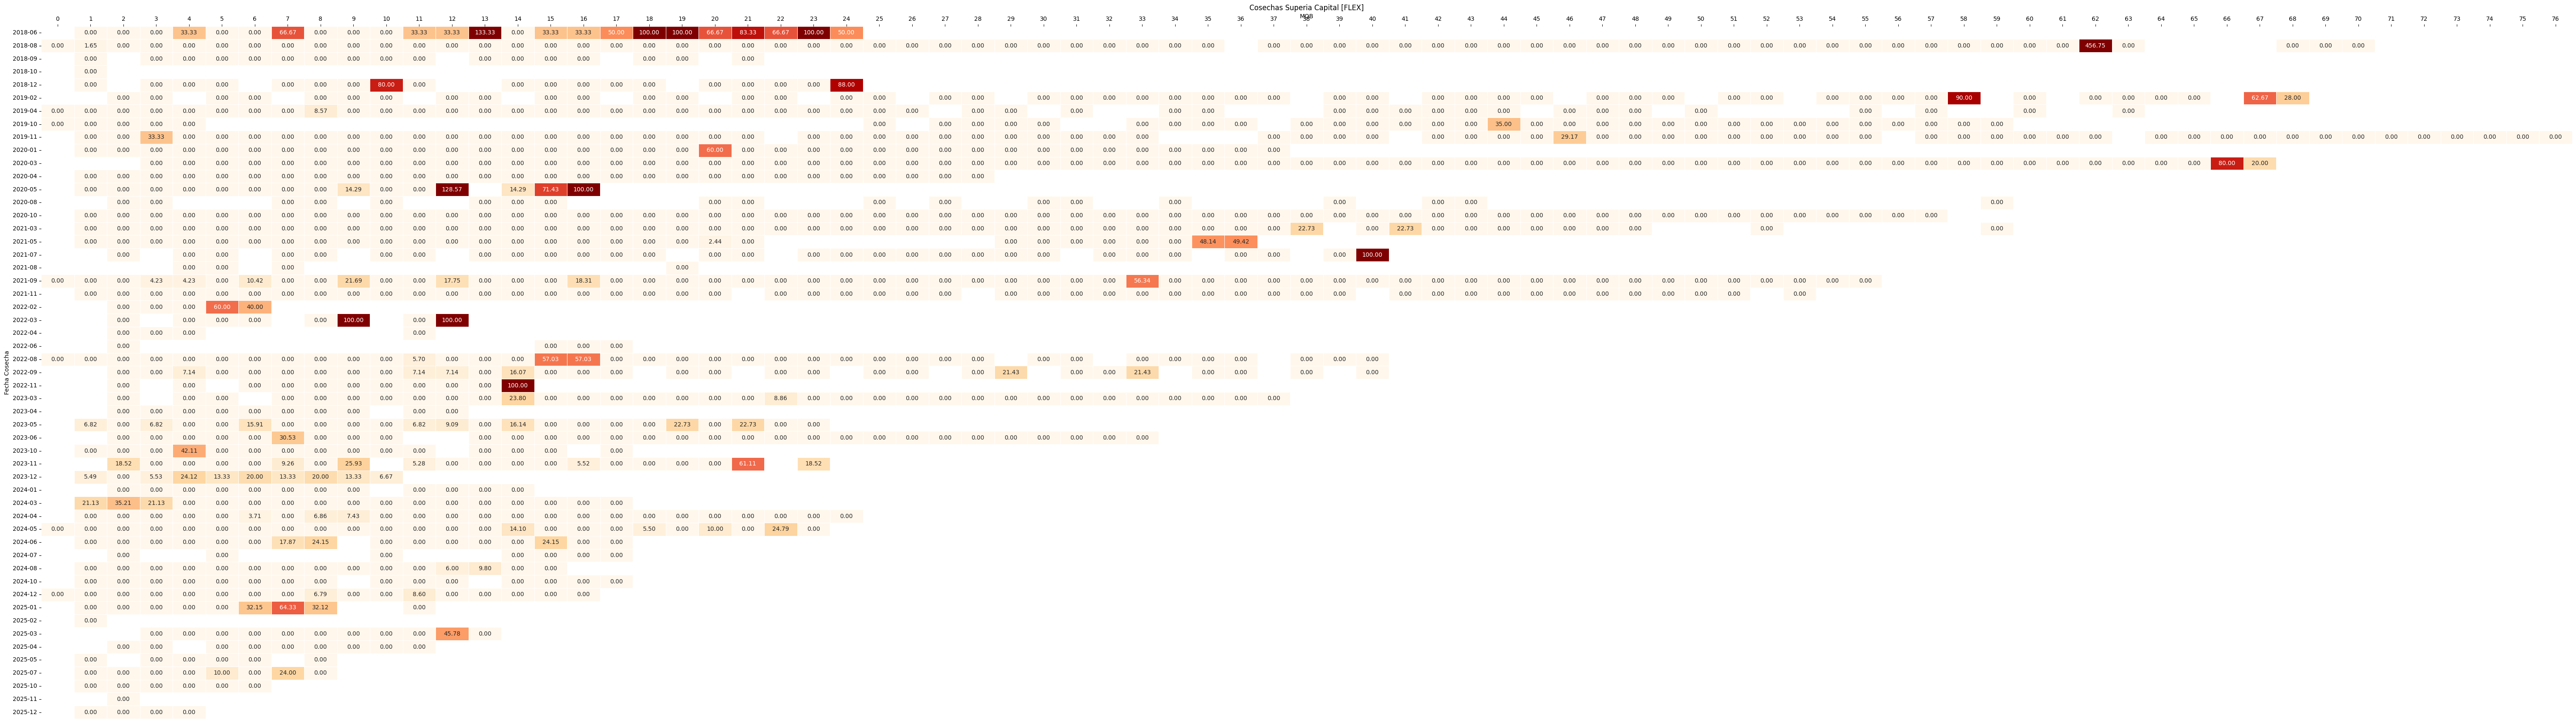

In [7]:
mc=mapacalor(producto.value)
rows,cols=mc.shape #Para ajuste de tamaño
plt.figure(figsize=(cols*1,rows*0.4))
ax=sns.heatmap(mc,annot= True,cmap="OrRd",fmt='.2f',vmax=100,linewidths=.5,cbar=False)
ax.xaxis.tick_top()
ax.xaxis.label_position='top'
ax.set(title='Cosechas Superia Capital [FLEX]',ylabel='Fecha Cosecha')
plt.show()


## **TIEMPO DE VIDA POR COSECHA (Medianas)**

In [8]:
#Primer atraso Flex(por cliente)
cfpp=flexpp[flexpp['DPD']>0].groupby('Line')['MOB'].min().reset_index()
cfdiv=flexdiv[flexdiv['DPD']>0].groupby('Line')['MOB'].min().reset_index()
#Clientes consolidado
#cfi=flex[flex['DPD']>0].groupby(['Line','MOB'],as_index=False).agg({'DPD':'max'}).reset_index()
cf=flex[flex['DPD']>0].groupby('Line')['MOB'].min().reset_index()
print('Toda la cartera Flex:\n',cf['MOB'].describe())
print('Divisas:\n',cfdiv['MOB'].describe())
print('Peso-Peso:\n',cfpp['MOB'].describe())

Toda la cartera Flex:
 count    47.000000
mean     16.297872
std      17.884794
min       1.000000
25%       5.500000
50%       9.000000
75%      17.500000
max      67.000000
Name: MOB, dtype: float64
Divisas:
 count    22.000000
mean     14.954545
std      14.591182
min       1.000000
25%       6.000000
50%      10.000000
75%      14.000000
max      62.000000
Name: MOB, dtype: float64
Peso-Peso:
 count    29.000000
mean     16.448276
std      19.280979
min       1.000000
25%       4.000000
50%      10.000000
75%      15.000000
max      67.000000
Name: MOB, dtype: float64


In [9]:
#Vida en cartera
cfppv=flexpp.groupby('Line')['MOB'].max().reset_index()
cfdivv=flexdiv.groupby('Line')['MOB'].max().reset_index()
#Clientes consolidado
cfv=flex.groupby(['Line','Name','Product'],as_index=False).agg({'MOB':'max'}).reset_index()
#cf=flex.groupby('Line')['MOB'].min().reset_index()
print('Toda la cartera Flex:\n',cfv['MOB'].describe())
print('Divisas:\n',cfdivv['MOB'].describe())
print('Peso-Peso:\n',cfppv['MOB'].describe())

Toda la cartera Flex:
 count    118.000000
mean      22.855932
std       18.540450
min        0.000000
25%       11.000000
50%       17.000000
75%       31.750000
max       76.000000
Name: MOB, dtype: float64
Divisas:
 count    55.000000
mean     18.981818
std      16.108993
min       0.000000
25%       8.000000
50%      15.000000
75%      23.000000
max      70.000000
Name: MOB, dtype: float64
Peso-Peso:
 count    63.000000
mean     26.238095
std      19.943237
min       1.000000
25%      12.000000
50%      21.000000
75%      38.500000
max      76.000000
Name: MOB, dtype: float64


## **ESTIMACION DE KAPLAN MEIER**

Para estimar el tiempo de vida de las líneas de crédito flex otorgadas por Superia se utilizó la estimación de Kaplan Meier, la cual es una técnica estadística utilizada para analizar el tiempo hasta que ocurre un evento.

El modelo de Kaplan Meier estima la función de supervivencia, que representa la probabilidad de que el evento de interés no ha ocurrido hasta cierto tiempo. Este modelo estima la probabilidad de manera escalonada y no paramétrica, ajustando el número de eventos y de individuos expuestos al riesgo en cada punto. Una de las ventajas de su aplicación, es que maneja correctamente los datos censurados, donde el evento de interés no ha ocurrido para el final del tiempo de estudio. En lugar de eliminarlos, los usa parcialmente hasta el momento en el que dejan de observarse, evitando así sesgos de estimación.

### Tiempo de vida (Duración de un crédito)
**Nota:** Independientemente del motivo del cierre

In [10]:
#CONSOLIDADO
flexldc=data_ldc[(data_ldc['Product']=='FLEX')&(data_ldc['Amount']>100000)]
flexldc['Plazo']=flexldc['Line'].map(flexi.groupby('Line')['Plazo'].max()).fillna(2)
flexldc=flexldc[flexldc['Plazo']>1]
flexldc['MOB']=flexldc['Line'].map(flex.groupby('Line')['MOB'].max()).fillna(0)
flexldc['Evento']=np.where(flexldc['Status']=='ACTIVO',0,1).astype(int) #1: Terminó el crédito #0: Siguen activos
#PESO-PESO
flexldcpp=data_ldc[(data_ldc['Product']=='FLEX')&(data_ldc['Amount']>100000)&((data_ldc['Line'].isin(filtropp['Line'])))]
flexldcpp['MOB']=flexldcpp['Line'].map(flexpp.groupby('Line')['MOB'].max())
flexldcpp['Evento']=np.where(flexldcpp['Status']=='ACTIVO',0,1).astype(int)
#DIVISAS
flexldcdiv=data_ldc[(data_ldc['Product']=='FLEX')&(data_ldc['Amount']>100000)&((data_ldc['Line'].isin(filtrodiv['Line'])))]
flexldcdiv['MOB']=flexldcdiv['Line'].map(flexdiv.groupby('Line')['MOB'].max())
flexldcdiv['Evento']=np.where(flexldcdiv['Status']=='ACTIVO',0,1).astype(int)

#SELECCIONAR PRODUCTO A ANALIZAR
an=tv(producto.value)
an['Originacion']=an['Originacion'].dt.year

/tmp/ipykernel_10418/1103513342.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flexldc['Plazo']=flexldc['Line'].map(flexi.groupby('Line')['Plazo'].max()).fillna(2)
/tmp/ipykernel_10418/1103513342.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flexldcpp['MOB']=flexldcpp['Line'].map(flexpp.groupby('Line')['MOB'].max())
/tmp/ipykernel_10418/1103513342.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

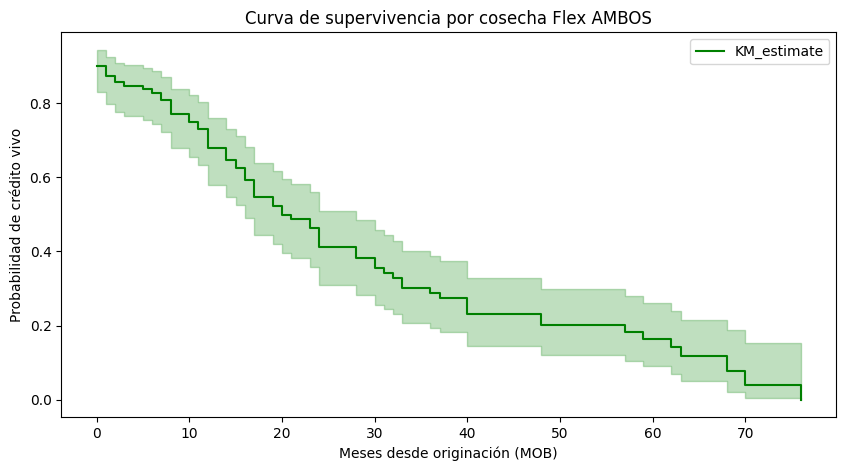

,Clientes acreditados:,Creditos activos a la fecha:,Probabilidad de sobrevivir 12 meses:,Probabilidad de sobrevivir 24 meses:,El 50% de los créditos termina en el mes:
0,112,33,0.678946,0.411001,20.0


In [11]:
plt.figure(figsize=(10,5))
kmftv=KaplanMeierFitter()
descr=[]
kmftv.fit(
      durations=an['MOB'],
      event_observed=an['Evento']
  )

descr.append(
      {
        'Clientes acreditados:':len(an),
        'Creditos activos a la fecha:':len(an[an['Evento']==0]),
        'Probabilidad de sobrevivir 12 meses:':kmftv.predict(12),
        'Probabilidad de sobrevivir 24 meses:':kmftv.predict(24),
        'El 50% de los créditos termina en el mes:':kmftv.median_survival_time_
      })

kmftv.plot_survival_function(color='green')

#ax=plt.gca()
#ax.xaxis.set_major_locator(MultipleLocator(5))
df_descriptv=pd.DataFrame(descr)
plt.title(f"Curva de supervivencia por cosecha Flex {producto.value}")
plt.xlabel("Meses desde originación (MOB)")
plt.ylabel("Probabilidad de crédito vivo")
plt.show()
df_descriptv

**Conclusión:**


*   Considerando la cartera completa, y tomando en cuenta solamente el tiempo de uso de las líneas, independientemente de la causa del cierre, la mediana de permanencia es de 24 meses, esto es, 50% de los créditos se dejaron de utilizar antes del mes 24.
*   Sin embargo, al tomar todo el histórico, combina las diferentes cosechas de crédito, lo que significa que tienen distinta madurez, por lo que el resultado puede estar sesgado por las cosechas más antiguas.
*   Como referencia histórica, el tiempo de utilización ha sido de 24 meses, más no es el tiempo de vida definitivo.

### *Por Cosecha*

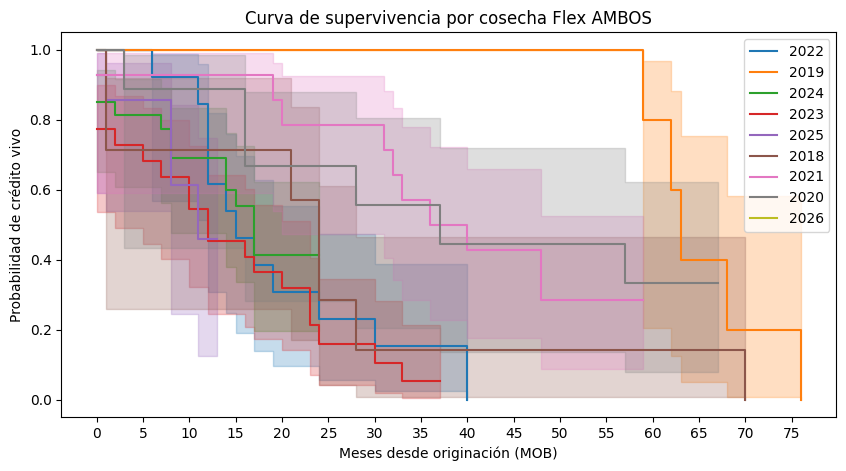

,Cosecha,Probabilidad de sobrevivir 12 meses:,Probabilidad de sobrevivir 24 meses:,El 50% de los créditos termina en el mes:
5,2018,0.714286,0.285714,24.0
1,2019,1.000000,1.000000,63.0
7,2020,0.888889,0.666667,37.0
6,2021,0.928571,0.785714,40.0
0,2022,0.615385,0.230769,15.0
3,2023,0.454545,0.159091,12.0
2,2024,0.691162,0.414697,17.0
4,2025,0.459184,0.459184,11.0
8,2026,1.000000,1.000000,inf


In [12]:
#an=an[(an['Originacion']>=2018)&(an['Originacion']<=2023)]
plt.figure(figsize=(10,5))
kmf=KaplanMeierFitter()
descriptivos=[]
for cosecha in an['Originacion'].unique():
  subset=an[an['Originacion']==cosecha]

  kmf.fit(
      durations=subset['MOB'],
      event_observed=subset['Evento'],
      label=str(cosecha)
  )

  descriptivos.append(
      {
          'Cosecha':cosecha,
          #'Clientes acreditados:':len(subset),
          #'Creditos activos a la fecha:':len(subset[subset['Evento']==0]),
          'Probabilidad de sobrevivir 12 meses:':kmf.predict(12),
          'Probabilidad de sobrevivir 24 meses:':kmf.predict(24),
          'El 50% de los créditos termina en el mes:':kmf.median_survival_time_
      })

  kmf.plot_survival_function()
  #print(kmf.survival_function_)


ax=plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(5))
df_descriptivos=pd.DataFrame(descriptivos)
plt.title(f"Curva de supervivencia por cosecha Flex {producto.value}")
plt.xlabel("Meses desde originación (MOB)")
plt.ylabel("Probabilidad de crédito vivo")
plt.show()
df_descriptivos.sort_values(by='Cosecha')

**Conclusión:**


*   Las cosechas que presentaron una caída más rápido fue 2018 y 2025, lo que significa que salieron tempranamente, sin embargo, fueron las cosechas de 2023 y 2022 las que presentan mayores caidas en poco tiempo, a pesar de que no son caídas tan pronunciadas, pero fueron las que se deterioraron más rápido.
*   Se puede observar que las cosechas se van haciendo menos longevas, es decir su tiempo en cartera es más corto, a pesar de que se están cosechando más créditos, el 50% de los clientes dejan la cartera más rápido, sin embargo, esto puede estar influenciado por la madurez de las cosechas.
*   A pesar de que son menos longevas, no podemos concluir mucho debido a que no toma en cuenta la causa del cierre de línea.



### Tiempo de vida (Primer atraso)

**Nota:** Atrasos desde 1 día

In [13]:
#CONSOLIDADO
flexldc['DPD']=flexldc['Line'].map(flex.groupby('Line')['DPD'].max())
flexldc['MOB PA']=flexldc['Line'].map(cf.groupby('Line')['MOB'].min())
flexldc['Evento PA']=np.where(flexldc['MOB PA'].notna(),1,0).astype(int) #1: Se atrasó #0: No se atrasó
flexldc['MOB PA']=flexldc['MOB PA'].fillna(flexldc['MOB'])
#PESO-PESO
flexldcpp['DPD']=flexldc['Line'].map(flex.groupby('Line')['DPD'].max())
flexldcpp['MOB PA']=flexldcpp['Line'].map(cfpp.set_index('Line')['MOB'])
flexldcpp['Evento PA']=np.where(flexldcpp['MOB PA'].notna(),1,0).astype(int)
flexldcpp['MOB PA']=flexldcpp['MOB PA'].fillna(flexldcpp['MOB'])
#DIVISAS
flexldcdiv['MOB PA']=flexldcdiv['Line'].map(cfdiv.set_index('Line')['MOB'])
flexldcdiv['Evento PA']=np.where(flexldcdiv['MOB PA'].notna(),1,0).astype(int)
flexldcdiv['MOB PA']=flexldcdiv['MOB PA'].fillna(flexldcdiv['MOB'])
#SELECCIONAR PRODUCTO
anPA=tv(producto.value)

/tmp/ipykernel_10418/2295207247.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flexldcpp['DPD']=flexldc['Line'].map(flex.groupby('Line')['DPD'].max())
/tmp/ipykernel_10418/2295207247.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flexldcpp['MOB PA']=flexldcpp['Line'].map(cfpp.set_index('Line')['MOB'])
/tmp/ipykernel_10418/2295207247.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

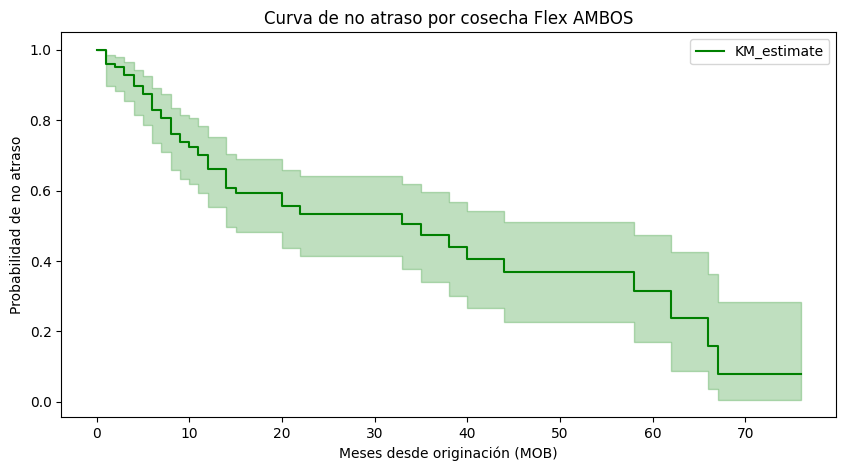

,Probabilidad de no atraso en 12 meses:,Probabilidad de no atraso en 24 meses:,El 50% de los créditos se atrasa en el mes:
0,0.66231,0.534683,35.0


In [ ]:
plt.figure(figsize=(10,5))
kmftvPA=KaplanMeierFitter()
descrPA=[]
kmftvPA.fit(
      durations=anPA['MOB PA'],
      event_observed=an['Evento PA']
  )

descrPA.append(
      {
        'Probabilidad de no atraso en 12 meses:':kmftvPA.predict(12),
        'Probabilidad de no atraso en 24 meses:':kmftvPA.predict(24),
        'El 50% de los créditos se atrasa en el mes:':kmftvPA.median_survival_time_
      })

kmftvPA.plot_survival_function(color='green')

#ax=plt.gca()
#ax.xaxis.set_major_locator(MultipleLocator(5))
df_descriptvPA=pd.DataFrame(descrPA)
plt.title(f"Curva de no atraso por cosecha Flex {producto.value}")
plt.xlabel("Meses desde originación (MOB)")
plt.ylabel("Probabilidad de no atraso")
plt.show()
df_descriptvPA

**Conclusión:**


*   La mediana del tiempo hasta que ocurre el primer atraso es mayor a la mediana del tiempo de permanencia en la cartera, lo que podría significar que los clientes dejan de utilizar la línea antes de llegar a atrasarse.

### *Por Cosecha*

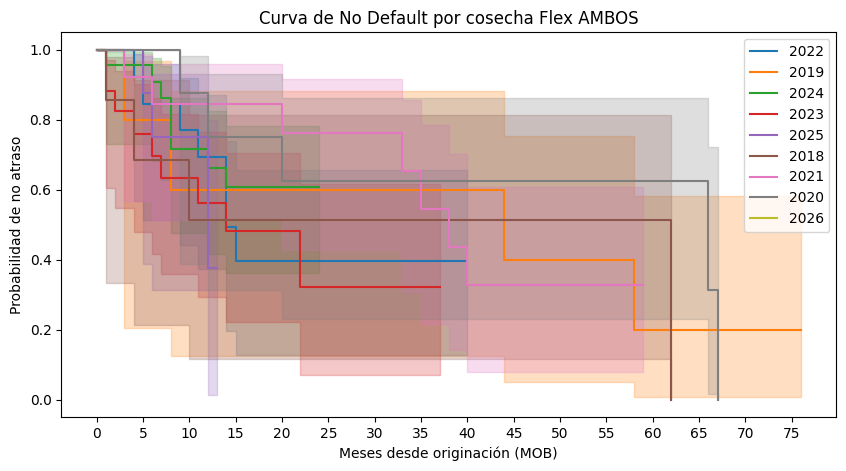

,Cosecha,Prob. de no atraso en 6 meses:,Prob. de no atraso en 12 meses:,Prob. de no atraso en 18 meses:,Prob. de no atraso en 24 meses:,El 50% de los créditos se atrasa en el mes:
5,2018,0.685714,0.514286,0.514286,0.514286,62.0
1,2019,0.800000,0.600000,0.600000,0.600000,44.0
7,2020,1.000000,0.750000,0.750000,0.625000,66.0
6,2021,0.846154,0.846154,0.846154,0.761538,38.0
0,2022,0.846154,0.692308,0.395604,0.395604,14.0
3,2023,0.696833,0.563097,0.482655,0.321770,14.0
2,2024,0.908696,0.662207,0.607023,0.607023,inf
4,2025,0.750000,0.375000,0.375000,0.375000,12.0
8,2026,1.000000,1.000000,1.000000,1.000000,inf


In [ ]:
#anPA=anPA[(anPA['Originacion']==2018)]#&(an['Originacion']<=2023)]
kmfPA=KaplanMeierFitter()
plt.figure(figsize=(10,5))
descriptivosPA=[]
for cosechas in anPA['Originacion'].unique():
  subsetPA=anPA[anPA['Originacion']==cosechas]

  kmfPA.fit(
      durations=subsetPA['MOB PA'],
      event_observed=subsetPA['Evento PA'],
      label=str(cosechas)
  )

  descriptivosPA.append(
      {
          'Cosecha':cosechas,
          'Prob. de no atraso en 6 meses:':kmfPA.predict(6),
          'Prob. de no atraso en 12 meses:':kmfPA.predict(12),
          'Prob. de no atraso en 18 meses:':kmfPA.predict(18),
          'Prob. de no atraso en 24 meses:':kmfPA.predict(24),
          'El 50% de los créditos se atrasa en el mes:':kmfPA.median_survival_time_
      })
  kmfPA.plot_survival_function()



ax=plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(5))
df_descriptivosPA=pd.DataFrame(descriptivosPA)
plt.title(f"Curva de No Default por cosecha Flex {producto.value}")
plt.xlabel("Meses desde originación (MOB)")
plt.ylabel("Probabilidad de no atraso")
plt.show()
df_descriptivosPA.sort_values(by='Cosecha')

**Conclusión:**


*   La unica cosecha que no presentó ningun atraso en sus primeros 6 meses es la de 2020.
*   Se puede observar que la probabilidad de no atraso se va deteriorando entre más tiempo se pasa en la cartera.
*   Se observa el mismo patrón que en el analisis pasado, Las cosechas más recientes tardan menos en atrasarse.
*   En base a este resultado nos arroja un punto importante de atención, estar monitoreando la cartera y su comportamiento cada 6 meses, sin embargo no podemos dar un tiempo de vida debido a que muchos atrasaso pueden ser administrativos o de un día, y no es óptimo cerrar una línea por un día de atraso.

### Tiempo de vida (Atrasos más largos)

**Nota:** Atrasos mayores a 15 días

In [ ]:
pi=flex[flex['DPD']>7]
pipp=flexpp[flexpp['DPD']>7]
pidiv=flexdiv[flexdiv['DPD']>7]

#Consolidado
flexldc['MOB INC']=flexldc['Line'].map(pi.groupby('Line')['MOB'].min())
flexldc['Evento INC']=np.where(flexldc['MOB INC'].notna(),1,0).astype(int) #1: Cayó en incumplimiento #0: No incumplió
flexldc['MOB INC']=flexldc['MOB INC'].fillna(flexldc['MOB'])
#PESO-PESO
flexldcpp['MOB INC']=flexldcpp['Line'].map(pipp.groupby('Line')['MOB'].min())
flexldcpp['Evento INC']=np.where(flexldcpp['MOB INC'].notna(),1,0).astype(int) #1: Cayó en incumplimiento #0: No incumplió
flexldcpp['MOB INC']=flexldcpp['MOB INC'].fillna(flexldcpp['MOB'])
#DIVISAS
flexldcdiv['MOB INC']=flexldcdiv['Line'].map(pidiv.groupby('Line')['MOB'].min())
flexldcdiv['Evento INC']=np.where(flexldcdiv['MOB INC'].notna(),1,0).astype(int) #1: Cayó en incumplimiento #0: No incumplió
flexldcdiv['MOB INC']=flexldcdiv['MOB INC'].fillna(flexldcdiv['MOB'])
#SELECCIONAR PRODUCTO
anIN=tv(producto.value)

/tmp/ipykernel_5129/2411808485.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flexldcpp['MOB INC']=flexldcpp['Line'].map(pipp.groupby('Line')['MOB'].min())
/tmp/ipykernel_5129/2411808485.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flexldcpp['Evento INC']=np.where(flexldcpp['MOB INC'].notna(),1,0).astype(int) #1: Cayó en incumplimiento #0: No incumplió
/tmp/ipykernel_5129/2411808485.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

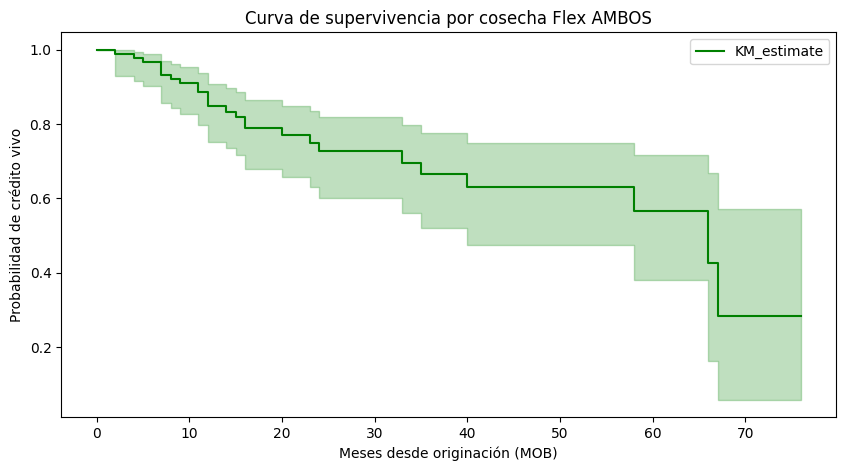

,Probabilidad de sobrevivir 12 meses:,Probabilidad de sobrevivir 24 meses:,El 50% de los créditos termina en el mes:
0,0.84763,0.726173,66.0


In [ ]:
plt.figure(figsize=(10,5))
kmftvIN=KaplanMeierFitter()
descrIN=[]
kmftvIN.fit(
      durations=anIN['MOB INC'],
      event_observed=anIN['Evento INC']
  )

descrIN.append(
      {
        'Probabilidad de sobrevivir 12 meses:':kmftvIN.predict(12),
        'Probabilidad de sobrevivir 24 meses:':kmftvIN.predict(24),
        'El 50% de los créditos termina en el mes:':kmftvIN.median_survival_time_
      })

kmftvIN.plot_survival_function(color='green')

#ax=plt.gca()
#ax.xaxis.set_major_locator(MultipleLocator(5))
df_descriptvIN=pd.DataFrame(descrIN)
plt.title(f"Curva de supervivencia por cosecha Flex {producto.value}")
plt.xlabel("Meses desde originación (MOB)")
plt.ylabel("Probabilidad de crédito vivo")
plt.show()
df_descriptvIN

### *Por Cosecha*

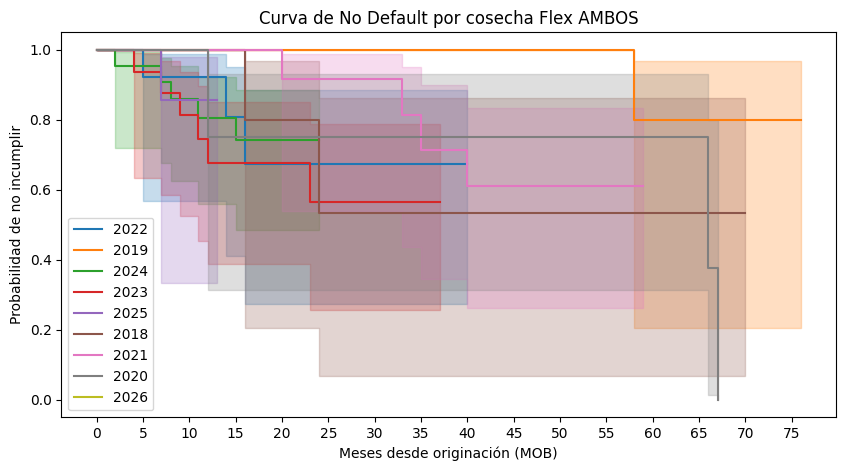

,Cosecha,Prob. de no default en 6 meses:,Prob. de no default en 12 meses:,Prob. de no default en 18 meses:,Prob. de no default en 24 meses:,El 50% incumple en el mes:
5,2018,1.000000,1.000000,0.800000,0.533333,inf
1,2019,1.000000,1.000000,1.000000,1.000000,inf
7,2020,1.000000,0.750000,0.750000,0.750000,66.0
6,2021,1.000000,1.000000,1.000000,0.916667,inf
0,2022,0.923077,0.923077,0.673077,0.673077,inf
3,2023,0.937500,0.677083,0.677083,0.564236,inf
2,2024,0.954545,0.805398,0.743444,0.743444,inf
4,2025,1.000000,0.857143,0.857143,0.857143,inf
8,2026,1.000000,1.000000,1.000000,1.000000,inf


In [ ]:
kmfINC=KaplanMeierFitter()
plt.figure(figsize=(10,5))
descriptivosINC=[]
for cosechasI in anIN['Originacion'].unique():
  subsetIN=anIN[anIN['Originacion']==cosechasI]

  kmfINC.fit(
      durations=subsetIN['MOB INC'],
      event_observed=subsetIN['Evento INC'],
      label=str(cosechasI)
  )

  descriptivosINC.append(
      {
          'Cosecha':cosechasI,
          'Prob. de no default en 6 meses:':kmfINC.predict(6),
          'Prob. de no default en 12 meses:':kmfINC.predict(12),
          'Prob. de no default en 18 meses:':kmfINC.predict(18),
          'Prob. de no default en 24 meses:':kmfINC.predict(24),
          'El 50% incumple en el mes:':kmfINC.median_survival_time_
      })
  kmfINC.plot_survival_function()



ax=plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(5))
df_descriptivosIN=pd.DataFrame(descriptivosINC)
plt.title(f"Curva de No Default por cosecha Flex {producto.value}")
plt.xlabel("Meses desde originación (MOB)")
plt.ylabel("Probabilidad de no incumplir")
plt.show()
df_descriptivosIN.sort_values(by='Cosecha')

**Conclusión:**


*   Los primeros 6 meses de vida de los créditos flex se mantienen estables, es decir la curva no presentan caidad pronunciadas, para aquellas cosechas que presentaron un atraso mayor a 7 días, o en otras cosechas no hay este tipo de atrasos en absoluto.
*   A partir de los 12 meses se comienza a observar un deterioro en las cosechas, su probabilidad de no caer en incumplimiento se va haciendo más baja, sobretodo en las cosechas 2020, 2023, 2024 y 2025.
*   Podemos observar el mismo patron que en el analisis pasado, entre más tiempo en la cartera, mayor es su probabilidad de caer en default.
*   Aquellas cosechas que se deterioraron más rápido son 2022, 2023 y 2024. Es imprtante analizar cómo van los clientes cosechados en esos años y quienes siguen en la cartera.
*   Sin embargo, aún no se cuenta con la información suficiente para estimar un tiempo de vida para las líneas de crédito, debido a que gran proporción de cliente no ha entrado en incumplimiento, o al menos no en atrasos de más de 15 días, por lo que no tenemos un parametro especifico para hacer punto de corte en cuántos mese debería durar.
*   La sugerencia es hacer revisones anuales para clientes de las líneas de crédito, para evaluar si existe viabilidad de seguir con la relación.
 En la mayoría de las cosechas no se alcanza el 50% de los eventos, por lo que la mediana de supervivencia no es estimable, esto es porque la mayoría de los clientes no cayeron en incumplimiento.

### *Proporcion incumplimientos*

In [ ]:
prop=round(len(anIN[(anIN['MOB PA']<=12)&(anIN['DPD']>30)])/len(anIN[(anIN['MOB PA']<=12)&(anIN['Evento PA']==1)])*100)
print('El',prop,'% de clientes que se atrasaron en su primeros 12 meses de acreditados cayeron en incumplimiento (+30 DIAS)')

El 37 % de clientes que se atrasaron en su primeros 12 meses de acreditados cayeron en incumplimiento (+30 DIAS)


### **COMPLEMENTO JESS**

In [ ]:
columnas=data_cierres.columns.difference(['Fecha Registro','Line','Empresa','Producto','LDC','Causa de cierre']).tolist()
for cols in columnas:
  data_cierres[cols]=data_cierres[cols].notna().astype(int)
dc=data_cierres[['Line']+ columnas]
dfcmerge=anIN.merge(dc,on='Line',how='left')
dfcmerge[columnas]=dfcmerge[columnas].fillna(0)

Causas de cierre por cosecha

In [ ]:
dfcmerge['evento']=dfcmerge[columnas].idxmax(axis=1)
dfcmerge.loc[dfcmerge[columnas].sum(axis=1)==0,'evento']='Activo'
tablaev=dfcmerge.groupby(['evento','Originacion'],as_index=False)['Person Id'].count()
tablaev[(tablaev['evento']=='Buro de Credito')]['Person Id'].sum()
t=tablaev.copy()
tablaev=pd.crosstab(dfcmerge['Originacion'],dfcmerge['evento'])
tablaev['Total acreditados (Flex)']=tablaev.sum(axis=1)

columns=tablaev.columns.tolist()
prop=tablaev.copy()
for cols in columns[:-1]:
  prop[cols]=tablaev[cols]/tablaev['Total acreditados (Flex)']
prop=prop.round(2)
prop

evento,Activo,Buro de Credito,Cambio de Producto,Decision del Cliente,Desconocido,Incumplimiento +90 dias,Utilizacion,Ventas,Total acreditados (Flex)
Originacion,,,,,,,,,
2018,0.00,0.00,0.00,0.00,0.57,0.14,0.14,0.14,7
2019,0.00,0.00,0.20,0.00,0.00,0.20,0.20,0.40,5
2020,0.33,0.00,0.00,0.11,0.22,0.22,0.00,0.11,9
2021,0.29,0.14,0.07,0.07,0.00,0.29,0.14,0.00,14
2022,0.00,0.23,0.15,0.08,0.08,0.15,0.15,0.15,13
2023,0.18,0.05,0.23,0.05,0.00,0.09,0.27,0.14,22
2024,0.52,0.00,0.11,0.04,0.00,0.00,0.26,0.07,27
2025,0.71,0.00,0.00,0.07,0.00,0.07,0.14,0.00,14
2026,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


Nota: en 2025 25% cayeron en incumplimiento --> solo es 1 (Zahori) es 25% porque solo 4 quedaton inactivos (flex)

Conclusiones:


*  La principal razón de salida de las líneas de crédito, es por utilización, se puede observar como se concentra en la mayoría de las cosechas, aumentando en las más recientes, alcanzando su pico más alto en 2024, que es justo una de las cosechas más rapidas en deteriorarse en el analisis anterior. Esto sugiere que la salidas ocurrieron por el cierre del ciclo comercial, más que por un deterioro en la calidad de la cartera.
*  Otro evento de interes es el Incumplimientos, razón que tiene mayor peso en cosechas antiguas, lo que puede indicar una mejor gestión de riesgos, ya sea en la originación o en el seguimiento de la cartera.
*   Se puede observar un incremento en líneas que se cierran por Decisión del cliente, lo que puede derivarse de nuevas politicas de crédito, como lo puede ser la disminución de líneas no garantizadas o acortar el plazo de utilización, etc.
*   En cuanto al cambio de producto, tiene una concentración importante en la cosecha de 2023, siendo esta la 2da mayor causa, probablemente por la implementación del nuevo porducto PAY, lo que ocacionó la migración de Peso-peso a este nuevo.


Cierres

In [ ]:
dfcmerge['Cierre']=np.where(dfcmerge['evento']=='Activo','Activo',dfcmerge['Due Date'].dt.year)
sub=dfcmerge[dfcmerge['Cierre']!='Activo']
tab=sub.groupby(['evento','Cierre'],as_index=False)['Person Id'].count()
tab[(tab['evento']=='Buro de Credito')]['Person Id'].sum()
tab=pd.crosstab(sub['Cierre'],sub['evento'])
tab['Total cierres']=tab.sum(axis=1)

column=tab.columns.tolist()
propt=tab.copy()
for cols in column[:-1]:
  propt[cols]=tab[cols]/tab['Total cierres']
propt=propt.round(2)
propt

evento,Buro de Credito,Cambio de Producto,Decision del Cliente,Desconocido,Incumplimiento +90 dias,Utilizacion,Ventas,Total cierres
Cierre,,,,,,,,
2018,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1
2021,0.00,0.00,0.00,0.80,0.20,0.00,0.00,5
2022,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1
2023,0.17,0.00,0.17,0.17,0.50,0.00,0.00,6
2024,0.11,0.06,0.11,0.06,0.22,0.17,0.28,18
2025,0.08,0.26,0.05,0.03,0.13,0.36,0.10,39
2026,0.00,0.17,0.17,0.00,0.00,0.33,0.33,6


# **PAY**

In [ ]:
payb=data_abonos[data_abonos['Product'].str.contains('PAY')]
pay=pay.rename(columns={'Period Number':'Cuotas'})
payb=payb.rename(columns={'Installment':'Cuota'})
payb['Originacion']=payb['Portfolio Id'].map(pay.set_index('Portfolio Id')['Originacion'])
#Unificar cuotas que se pagaron por partes
pagos_agrup= (
    payb.groupby(['Portfolio Id', 'Cuota']).agg({'Application Date': 'max','Capital':'sum','Penalty':'sum'}).reset_index()
)
#Insertar filas por ministraciones
pagos=pay.loc[pay.index.repeat(pay['Cuotas'])].assign(Cuota=lambda x: x.groupby('Portfolio Id').cumcount()+1)
payc=pagos.merge(pagos_agrup,on=['Portfolio Id','Cuota'],how='left')
payc['Application Date']=pd.to_datetime(payc['Application Date']).fillna(date.today())
def fcp(row):
  duedate=pd.to_datetime(row['Opening Date'])+relativedelta(months=row['Cuota'])
  return duedate

payc['Fecha vencimiento cuota']=payc.apply(fcp,axis=1)
payc=payc[pd.to_datetime(payc['Fecha vencimiento cuota'],errors='coerce')<=pd.to_datetime(date.today())]
payc['Moratorios']=payc['Penalty'].fillna(0)
def mobp1(row):
    dy=(pd.to_datetime(row['Opening Date']).year)-(pd.to_datetime(row['Originacion']).year)
    dm=(pd.to_datetime(row['Opening Date']).month)-(pd.to_datetime(row['Originacion']).month)
    MOBop=dy*12+dm+row['Cuota']
    return MOBop

payc['MOB']=payc.apply(mobp1,axis=1)

def dpdp(row):
  duedate=pd.to_datetime(row['Opening Date'])+relativedelta(months=row['Cuota'])
  DPDUP= pd.to_numeric((pd.to_datetime(row['Application Date'])-duedate).days,errors='coerce')
  if DPDUP<0:
    return 0
  else:
    if row['Loan Status']=="LIQUIDADO":
      if row['Moratorios']>0:
        return DPDUP
      else:
        return 0
    else:
      if pd.to_datetime(row['Application Date'])!=pd.to_datetime(date.today()):
        if row['Moratorios']>0:
          return DPDUP
        else:
          return 0
      else:
        return DPDUP

payc['DPD']=payc.apply(dpdp,axis=1)

def DPADP(fila):
    if fila['DPD']>0:
      return fila['Capital']
    else:
      return 0

payc['mvenc']=payc.apply(DPADP,axis=1)
def propmp(fil):
  if fil['Amount']==0:
    return 0
  else:
    return fil['mvenc']/fil['Amount']

fi=pd.to_datetime(input("Desde qué fecha deseas analizar: "))
ff=pd.to_datetime(input("Hasta qué fecha deseas analizar: "))
filtrop=payc[(payc['Originacion']>=fi) & (payc['Originacion']<=ff)]
sit_vencp=pd.pivot_table(
    filtrop,
    index=pd.Grouper(key='Originacion',freq='1M'),
    values=['mvenc'],
    aggfunc='sum'
)

filtro_monp=data_ldc[(data_ldc['Product'].str.contains('PAY')) & (data_ldc['Originacion']>=fi) & (data_ldc['Originacion']<=ff)]
sit_monp=pd.pivot_table(
    filtro_monp,
    index=pd.Grouper(key='Originacion',freq='1M'),
    values=['Amount'],
    aggfunc='sum'
)


sitp=pd.merge(sit_vencp,sit_monp,on='Originacion')

sit_vencp=sit_vencp.reset_index()
sit_monp=sit_monp.reset_index()

sitp['Indice']=sitp.apply(propmp,axis=1)


coh_datap=filtrop.groupby([pd.Grouper(key='Originacion',freq='1M'),'MOB'])['mvenc'].apply(np.sum)
coh_datap=coh_datap.reset_index()

coh_morap=coh_datap.pivot_table(
                              index='Originacion',
                              columns='MOB',
                              values='mvenc')


coh_desp=filtro_monp.groupby([pd.Grouper(key='Originacion',freq='1M')])['Amount'].apply(np.sum)
coh_desp=coh_desp.reset_index()

coh_count_desp =coh_desp.pivot_table(
                              index=pd.Grouper(key="Originacion",freq='1M'),
                              values='Amount')



#indicadores de columnas
indcp=coh_morap.divide(coh_count_desp.iloc[:,0],axis=0)
indcp=(indcp*100).round(4).dropna(how='all')
indcp.index=indcp.index.strftime('%Y-%m')
#indc=indc.fillna(0)

Desde qué fecha deseas analizar: 2024-01-01
Hasta qué fecha deseas analizar: 2026-03-26


/tmp/ipykernel_5129/4284915405.py:68: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper(key='Originacion',freq='1M'),
/tmp/ipykernel_5129/4284915405.py:76: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper(key='Originacion',freq='1M'),
/tmp/ipykernel_5129/4284915405.py:90: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  coh_datap=filtrop.groupby([pd.Grouper(key='Originacion',freq='1M'),'MOB'])['mvenc'].apply(np.sum)
/tmp/ipykernel_5129/4284915405.py:99: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  coh_desp=filtro_monp.groupby([pd.Grouper(key='Originacion',freq='1M')])['Amount'].apply(np.sum)
/tmp/ipykernel_5129/4284915405.py:103: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper

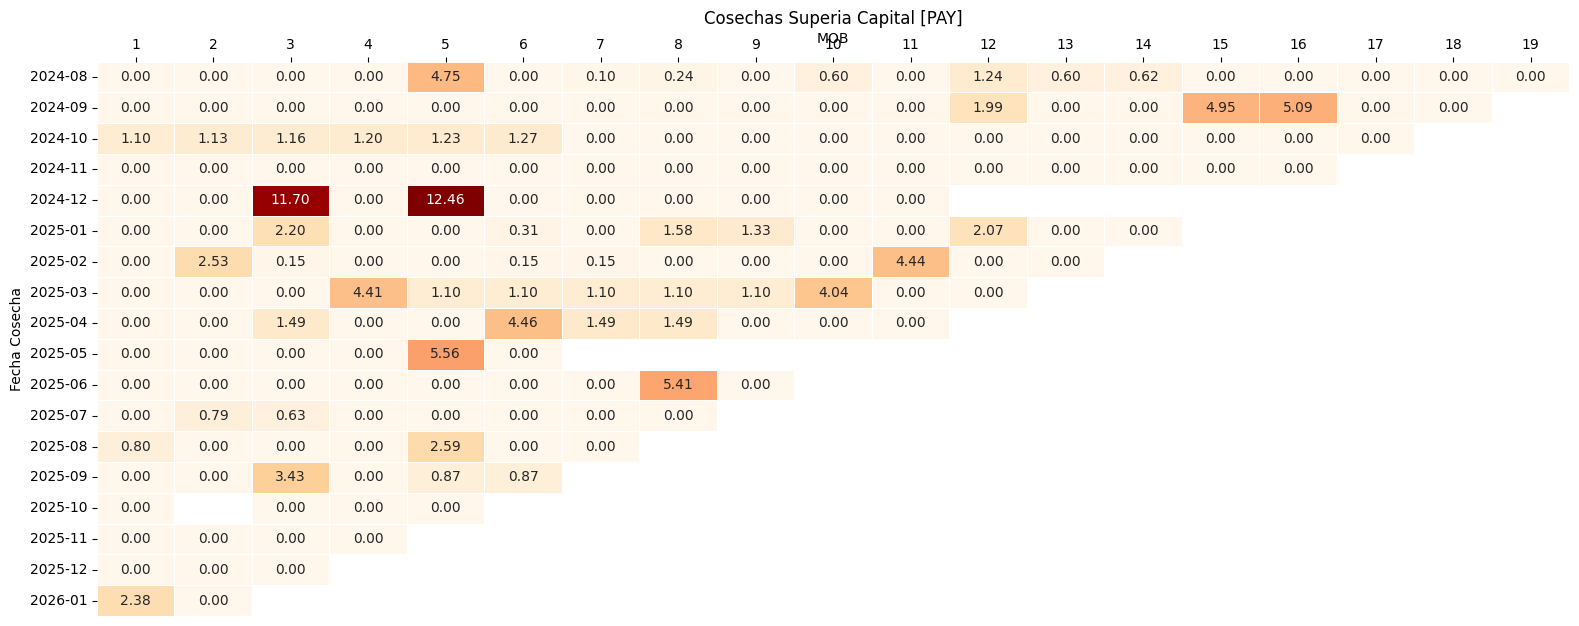

In [ ]:
rows,cols=indcp.shape #Para ajuste de tamaño
plt.figure(figsize=(cols*1,rows*0.4))
ax=sns.heatmap(indcp,annot= True,cmap="OrRd",fmt='.2f',linewidths=.5,cbar=False)
ax.xaxis.tick_top()
ax.xaxis.label_position='top'
ax.set(title='Cosechas Superia Capital [PAY]',ylabel='Fecha Cosecha')
plt.show()

In [ ]:
#CONSOLIDADO
payldc=data_ldc[(data_ldc['Product'].str.contains('PAY'))]
payldc['MOB']=payldc['Line'].map(payc.groupby('Line')['MOB'].max()).fillna(0)
payldc['Evento']=np.where(payldc['Status']=='ACTIVO',0,1).astype(int) #1: Terminó el crédito #0: Siguen activos

#SELECCIONAR PRODUCTO A ANALIZAR
payldc['Originacion']=payldc['Originacion'].dt.year

/tmp/ipykernel_5129/2692149152.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  payldc['MOB']=payldc['Line'].map(payc.groupby('Line')['MOB'].max()).fillna(0)
/tmp/ipykernel_5129/2692149152.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  payldc['Evento']=np.where(payldc['Status']=='ACTIVO',0,1).astype(int) #1: Terminó el crédito #0: Siguen activos
/tmp/ipykernel_5129/2692149152.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

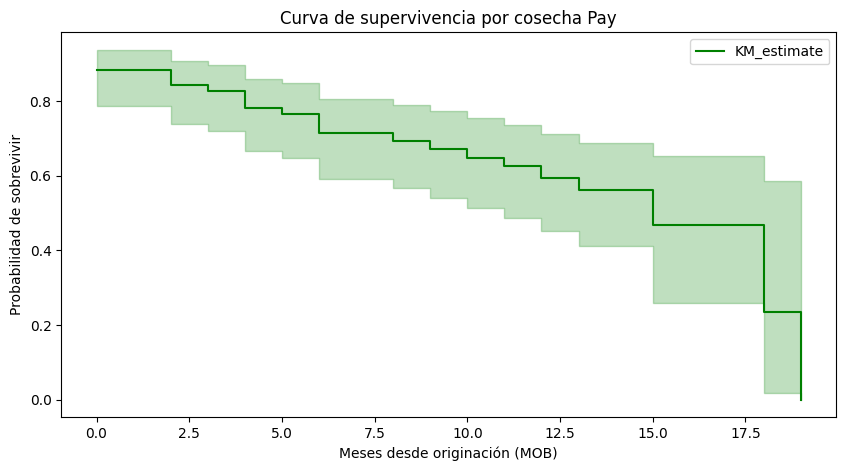

,Probabilidad de sobrevivir 12 meses:,Probabilidad de sobrevivir 24 meses:,El 50% de los créditos termina en el mes:
0,0.713978,0.59496,15.0


In [ ]:
plt.figure(figsize=(10,5))
kmftvPAY=KaplanMeierFitter()
descrPAY=[]
kmftvPAY.fit(
      durations=payldc['MOB'],
      event_observed=payldc['Evento']
  )

descrPAY.append(
      {
        'Probabilidad de sobrevivir 12 meses:':kmftvPAY.predict(6),
        'Probabilidad de sobrevivir 24 meses:':kmftvPAY.predict(12),
        'El 50% de los créditos termina en el mes:':kmftvPAY.median_survival_time_
      })

kmftvPAY.plot_survival_function(color='green')

#ax=plt.gca()
#ax.xaxis.set_major_locator(MultipleLocator(5))
df_descriptvPAY=pd.DataFrame(descrPAY)
plt.title(f"Curva de supervivencia por cosecha Pay")
plt.xlabel("Meses desde originación (MOB)")
plt.ylabel("Probabilidad de sobrevivir")
plt.show()
df_descriptvPAY

In [ ]:
dpcmerge=payldc.merge(dc,on='Line',how='left')
dpcmerge[columnas]=dpcmerge[columnas].fillna(0)
dpcmerge['evento']=dpcmerge[columnas].idxmax(axis=1)
dpcmerge.loc[dpcmerge[columnas].sum(axis=1)==0,'evento']='Activo'
tablaevp=dpcmerge.groupby(['evento','Originacion'],as_index=False)['Person Id'].count()
tp=tablaevp.copy()
tablaevp=pd.crosstab(dpcmerge['Originacion'],dpcmerge['evento'])
tablaevp['Total acreditados (Pay)']=tablaevp.sum(axis=1)

columnsp=tablaevp.columns.tolist()
propp=tablaevp.copy()
for cols in columnsp[:-1]:
  propp[cols]=tablaevp[cols]
propp=propp.round(2)
propp

evento,Activo,Buro de Credito,Cambio de Producto,Decision del Cliente,Incumplimiento +90 dias,Utilizacion,Ventas,Total acreditados (Pay)
Originacion,,,,,,,,
2024,6,0,11,1,1,1,1,21
2025,39,3,3,1,0,4,1,51
2026,5,0,0,0,0,0,0,5


In [ ]:
i

,RFC,Name,Product,evento
0,OSE170131J93,A Y O SERVICIOS,PAY,Activo
3,AFH171011LH8,AGRICOLA FH,SUPERIA PAY,Activo
5,ACO181002NU8,APIO CONSULTING,PAY,Activo
6,ARC200819JL8,ARCHIBRAND SA DE CV,PAY,Activo
11,BPO190117759,BERRIES POZOS,PAY,Activo
12,BSA211118NA2,BT SERVICIOS AUTOMOTRICES,PAY,Activo
13,CMA991026JYA,CENTRAL DE MANGUERAS Y ACCESORIOS,PAY,Activo
15,CER1302149U7,CONFIANZA EN RETIRO,PAY,Activo
16,CCB851031FQ7,CREACIONES CAM-BROS,PAY,Activo
17,CBO160125ADA,CYPROS BOILERS,PAY,Activo


In [ ]:
dpcmerge['RFC']=dpcmerge['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
inn=dpcmerge[(dpcmerge['evento']=='Cambio de Producto')]
i=inn[['RFC','Name','Product','evento']]
ac=dpcmerge[(dpcmerge['evento']=='Activo')]
ac=ac[['RFC','Name','Product','evento']]

In [ ]:
o=i.merge(ac,on='RFC',how='left')
o

,RFC,Name_x,Product_x,evento_x,Name_y,Product_y,evento_y
0,ALE1510286Z6,ABBE LEASING,SUPERIA PAY,Cambio de Producto,NaN,NaN,NaN
1,ARC200819JL8,ARCHIBRAND SA DE CV,SUPERIA PAY,Cambio de Producto,ARCHIBRAND SA DE CV,PAY,Activo
2,ARV020513EF0,ARVENSIS SA DE CV,SUPERIA PAY,Cambio de Producto,NaN,NaN,NaN
3,CMA991026JYA,CENTRAL DE MANGUERAS Y ACCESORIOS,SUPERIA PAY,Cambio de Producto,CENTRAL DE MANGUERAS Y ACCESORIOS,PAY,Activo
4,FMP150225LW3,FABRICACION Y MANUFACTURA DE PERFILES,SUPERIA PAY,Cambio de Producto,FABRICACION Y MANUFACTURA DE PERFILES,PAY,Activo
5,FAM950804JG0,FARMACIA AGROQUIMICA DE MEXICO,SUPERIA PAY,Cambio de Producto,FARMACIA AGROQUIMICA DE MEXICO,PAY,Activo
6,GCO110610UK8,GRUPO CONOCIDO,SUPERIA PAY,Cambio de Producto,GRUPO CONOCIDO,PAY,Activo
7,ERE0612084T8,LAS ESTACAS Y EL REFUGIO,SUPERIA PAY,Cambio de Producto,LAS ESTACAS Y EL REFUGIO,PAY,Activo
8,ERE0612084T8,LAS ESTACAS Y EL REFUGIO,PAY,Cambio de Producto,LAS ESTACAS Y EL REFUGIO,PAY,Activo
9,LNF101201LP4,LEVA NEGOCIOS Y FRANQUICIAS,SUPERIA PAY,Cambio de Producto,LEVA NEGOCIOS Y FRANQUICIAS,PAY,Activo


# **REGRESIÓN DE COX CON VARIABLES EXPLICATIVAS**

Modeo predictivo que estima la función de supervivencia con determinados valores de las variables predictoras.

SIMPLE (solo ver que variables impactan)

### **Variables explicativas:**
  1.   Año de cosecha
  2.   Score Pyme (vemos) --> Solo para cosechas de 2024 a 2025 (PAY)
  3.   Monto de línea
  4.   Venta anual (año anterior acreditacion)
